In [ ]:
%pip install librosa soundfile -q

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from IPython.display import Audio, display

In [38]:
class CFG:
    SAMPLE_RATE = 16000
    SEGMENT = 32000

    N_FFT = 512
    HOP = 128

    BATCH_SIZE = 8
    EPOCHS = 8
    LR = 1e-3

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    ROOT = Path("/kaggle/input/datasets/muhmagdy/valentini-noisy")


print("DEVICE:", CFG.DEVICE)

DEVICE: cpu


In [ ]:
all_files = sorted(list(CFG.ROOT.rglob("*.wav")))

print("FILES:", len(all_files))

if len(all_files) == 0:
    raise Exception("No wav files found")


split = int(0.9 * len(all_files))
train_files = all_files[:split]
val_files = all_files[split:]

FILES: 70942


In [ ]:
class AudioDataset(Dataset):

    def __init__(self, files, segment=32000, train=True):
        self.files = files
        self.segment = segment
        self.train = train

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        audio, sr = torchaudio.load(self.files[idx])
        audio = audio.mean(0).float()

        # safe normalize
        mx = audio.abs().max()
        if mx > 0:
            audio = audio / mx

        noise = torch.randn_like(audio) * 0.02
        noisy = audio + noise

        # pad
        if len(audio) < self.segment:
            pad = self.segment - len(audio)
            audio = F.pad(audio, (0, pad))
            noisy = F.pad(noisy, (0, pad))

        # crop
        if self.train:
            start = random.randint(0, len(audio) - self.segment)
            audio = audio[start:start+self.segment]
            noisy = noisy[start:start+self.segment]
        else:
            audio = audio[:self.segment]
            noisy = noisy[:self.segment]

        return noisy, audio


train_ds = AudioDataset(train_files, train=True)
val_ds = AudioDataset(val_files, train=False)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False)

In [ ]:
class DenoisingAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

        self.register_buffer(
            "window",
            torch.hann_window(CFG.N_FFT)
        )

    def forward(self, noisy):

        spec = torch.stft(
            noisy,
            n_fft=CFG.N_FFT,
            hop_length=CFG.HOP,
            window=self.window,
            return_complex=True,
            center=True
        )

        mag = spec.abs().unsqueeze(1)
        phase = torch.angle(spec)

        x = self.encoder(mag)
        x = self.decoder(x).squeeze(1)

        if x.shape[-2] != phase.shape[-2] or x.shape[-1] != phase.shape[-1]:

            x = F.interpolate(
                x.unsqueeze(1),
                size=(phase.shape[-2], phase.shape[-1]),
                mode="bilinear",
                align_corners=False
            ).squeeze(1)

        complex_spec = torch.polar(x, phase)

        audio = torch.istft(
            complex_spec,
            n_fft=CFG.N_FFT,
            hop_length=CFG.HOP,
            window=self.window,
            length=noisy.shape[-1],
            center=True
        )

        return audio


model = DenoisingAutoencoder().to(CFG.DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=CFG.LR)
criterion = nn.L1Loss()

In [42]:
train_losses = []

print("\nTRAINING...\n")

for epoch in range(CFG.EPOCHS):

    model.train()
    total_loss = 0

    for noisy, clean in train_loader:

        noisy = noisy.to(CFG.DEVICE)
        clean = clean.to(CFG.DEVICE)

        enhanced = model(noisy)

        min_len = min(enhanced.shape[-1], clean.shape[-1])
        enhanced = enhanced[:, :min_len]
        clean = clean[:, :min_len]

        loss = criterion(enhanced, clean)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg = total_loss / len(train_loader)
    train_losses.append(avg)

    print(f"Epoch {epoch+1}/{CFG.EPOCHS} Loss: {avg:.4f}")


TRAINING...

Epoch 1/8 Loss: 0.0828
Epoch 2/8 Loss: 0.0829
Epoch 3/8 Loss: 0.0827
Epoch 4/8 Loss: 0.0828
Epoch 5/8 Loss: 0.0829
Epoch 6/8 Loss: 0.0828
Epoch 7/8 Loss: 0.0828
Epoch 8/8 Loss: 0.0828


In [49]:
print(model.encoder[0].weight)

Parameter containing:
tensor([[[[-0.4119,  0.0326, -0.0893],
          [ 0.1706,  0.2937,  0.2156],
          [-0.2829,  0.2804, -0.4561]]],


        [[[-0.1427,  0.3513,  0.3960],
          [ 0.0035, -0.1665, -0.2714],
          [ 0.0732, -0.0265, -0.0925]]],


        [[[ 0.1107,  0.2156,  0.1910],
          [ 0.0350,  0.1793,  0.1835],
          [ 0.0729,  0.0207,  0.1261]]],


        [[[ 0.0614, -0.4468,  0.5663],
          [-0.0967, -0.1241, -0.0404],
          [ 0.0459, -0.3077,  0.1702]]],


        [[[-0.1621, -0.1116, -0.2035],
          [-0.1045, -0.1089, -0.0838],
          [-0.0826, -0.0932, -0.1674]]],


        [[[ 0.1581,  0.1384,  0.0575],
          [ 0.0829,  0.1049,  0.0701],
          [-0.0798, -0.1738, -0.1029]]],


        [[[-0.1152,  0.0135, -0.1347],
          [-0.1976, -0.0968, -0.1796],
          [-0.0391,  0.0282, -0.0582]]],


        [[[-0.1224,  0.1012, -0.0737],
          [ 0.0954,  0.3664,  0.1043],
          [ 0.1721,  0.2135, -0.0237]]],


        [[

In [43]:
torch.save(model.state_dict(), "/kaggle/working/dae_model.pth")
print("MODEL SAVED")

MODEL SAVED


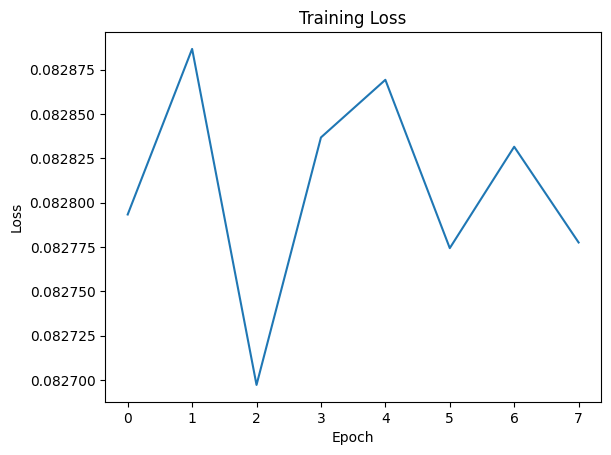

In [44]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [45]:
model.eval()

noisy, clean = val_ds[0]
noisy_in = noisy.unsqueeze(0).to(CFG.DEVICE)

with torch.no_grad():
    enhanced = model(noisy_in)

In [46]:
print("NOISY")
display(Audio(noisy.numpy(), rate=CFG.SAMPLE_RATE))

print("ENHANCED")
display(Audio(enhanced.squeeze().cpu().numpy(), rate=CFG.SAMPLE_RATE))

NOISY


ENHANCED


In [47]:
torchaudio.save(
    "/kaggle/working/enhanced.wav",
    enhanced.cpu(),
    CFG.SAMPLE_RATE
)

print("ENHANCED SAVED")

ENHANCED SAVED


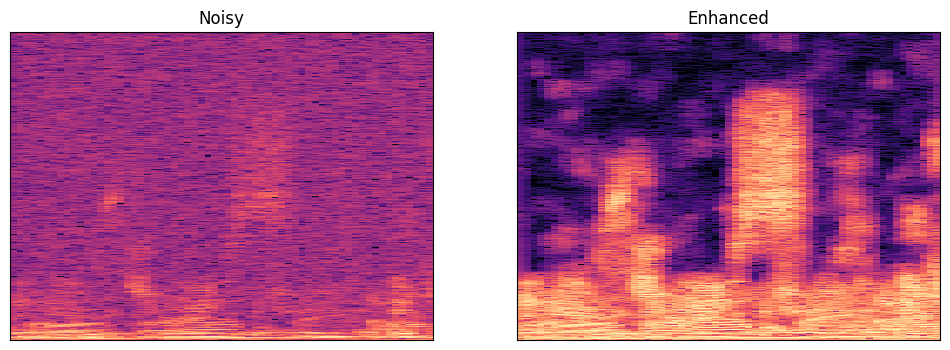

In [48]:
noisy_np = noisy.numpy()
enh_np = enhanced.squeeze().cpu().numpy()

spec1 = librosa.amplitude_to_db(np.abs(librosa.stft(noisy_np)), ref=np.max)
spec2 = librosa.amplitude_to_db(np.abs(librosa.stft(enh_np)), ref=np.max)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
librosa.display.specshow(spec1, sr=CFG.SAMPLE_RATE)
plt.title("Noisy")

plt.subplot(1,2,2)
librosa.display.specshow(spec2, sr=CFG.SAMPLE_RATE)
plt.title("Enhanced")

plt.show()